# RetailPulse – Inventory Optimization

## AI-Powered Inventory Risk Analysis

**Author:** Gulafsha

### Objective

Analyze product demand and generate inventory recommendations to reduce overstocking and stock shortages.

### Business Goals

- Optimize inventory levels
- Reduce holding costs
- Prevent stock-outs
- Improve inventory planning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries Loaded Successfully ✅")

Libraries Loaded Successfully ✅


In [2]:
df = pd.read_csv("../data/cleaned_online_retail.csv")

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Month,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,2009-12,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009-12,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009-12,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,2009-12,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,2009-12,30.0


In [3]:
# Create product-wise inventory summary

inventory = (
    df.groupby(["StockCode", "Description"])
      .agg(
          Total_Quantity=("Quantity", "sum"),
          Total_Revenue=("Revenue", "sum"),
          Total_Orders=("Invoice", "nunique")
      )
      .reset_index()
)

inventory.head()

,StockCode,Description,Total_Quantity,Total_Revenue,Total_Orders
0,10002,INFLATABLE POLITICAL GLOBE,7971,6333.76,310
1,10002R,ROBOT PENCIL SHARPNER,4,20.57,3
2,10080,GROOVY CACTUS INFLATABLE,12,10.20,5
3,10109,BENDY COLOUR PENCILS,4,1.68,1
4,10120,DOGGY RUBBER,487,105.57,47


In [4]:
# Convert InvoiceDate to datetime

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# Daily sales per product

daily_sales = (
    df.groupby(["StockCode", "Description", "InvoiceDate"])
      .agg(Daily_Sales=("Quantity", "sum"))
      .reset_index()
)

daily_sales.head()

,StockCode,Description,InvoiceDate,Daily_Sales
0,10002,INFLATABLE POLITICAL GLOBE,2009-12-01 09:08:00,12
1,10002,INFLATABLE POLITICAL GLOBE,2009-12-03 13:49:00,1
2,10002,INFLATABLE POLITICAL GLOBE,2009-12-03 19:13:00,1
3,10002,INFLATABLE POLITICAL GLOBE,2009-12-03 20:03:00,4
4,10002,INFLATABLE POLITICAL GLOBE,2009-12-04 08:46:00,12


In [5]:
average_demand = (
    daily_sales.groupby(["StockCode", "Description"])
               .agg(
                   Average_Daily_Demand=("Daily_Sales", "mean"),
                   Maximum_Daily_Demand=("Daily_Sales", "max")
               )
               .reset_index()
)

average_demand.head()

,StockCode,Description,Average_Daily_Demand,Maximum_Daily_Demand
0,10002,INFLATABLE POLITICAL GLOBE,25.879870,400
1,10002R,ROBOT PENCIL SHARPNER,1.333333,2
2,10080,GROOVY CACTUS INFLATABLE,2.400000,6
3,10109,BENDY COLOUR PENCILS,4.000000,4
4,10120,DOGGY RUBBER,10.361702,60


In [6]:
inventory = inventory.merge(
    average_demand,
    on=["StockCode", "Description"],
    how="left"
)

inventory.head()

,StockCode,Description,Total_Quantity,Total_Revenue,Total_Orders,Average_Daily_Demand,Maximum_Daily_Demand
0,10002,INFLATABLE POLITICAL GLOBE,7971,6333.76,310,25.879870,400
1,10002R,ROBOT PENCIL SHARPNER,4,20.57,3,1.333333,2
2,10080,GROOVY CACTUS INFLATABLE,12,10.20,5,2.400000,6
3,10109,BENDY COLOUR PENCILS,4,1.68,1,4.000000,4
4,10120,DOGGY RUBBER,487,105.57,47,10.361702,60


## ABC Inventory Analysis

Products are classified according to cumulative revenue contribution.

- A → High-value products
- B → Medium-value products
- C → Low-value products

In [12]:
# ==========================================
# ABC Analysis
# ==========================================

inventory = inventory.sort_values(
    "Total_Revenue",
    ascending=False
)

inventory["Revenue_Percentage"] = (
    inventory["Total_Revenue"]
    / inventory["Total_Revenue"].sum()
)

inventory["Cumulative_Revenue"] = (
    inventory["Revenue_Percentage"].cumsum()
)

inventory["ABC_Class"] = np.where(
    inventory["Cumulative_Revenue"] <= 0.80,
    "A",
    np.where(
        inventory["Cumulative_Revenue"] <= 0.95,
        "B",
        "C"
    )
)

inventory.head()

,StockCode,Description,Total_Quantity,Total_Revenue,Total_Orders,Average_Daily_Demand,Maximum_Daily_Demand,Safety_Stock,Reorder_Level,Inventory_Status,Revenue_Percentage,Cumulative_Revenue,ABC_Class
4717,M,Manual,2764,262577.36,512,5.398438,144,1512.0,37.789062,Healthy,0.025563,0.025563,A
1858,22423,REGENCY CAKESTAND 3 TIER,13685,169912.76,2019,6.904642,360,3780.0,48.332492,Overstock,0.016542,0.042105,A
4114,85123A,WHITE HANGING HEART T-LIGHT HOLDER,58386,158305.72,3281,17.970452,936,9828.0,125.793167,Overstock,0.015412,0.057517,A
4716,DOT,DOTCOM POSTAGE,730,116408.71,730,1.155063,4,42.0,8.085443,Overstock,0.011333,0.068849,A
3773,84879,ASSORTED COLOUR BIRD ORNAMENT,45228,72890.19,1412,32.213675,2880,30240.0,225.495726,Healthy,0.007096,0.075946,A


In [7]:
# Inventory assumptions

Lead_Time = 7
Safety_Factor = 1.5

inventory["Safety_Stock"] = (
    inventory["Maximum_Daily_Demand"] *
    Lead_Time *
    Safety_Factor
)

inventory["Reorder_Level"] = (
    inventory["Average_Daily_Demand"] *
    Lead_Time
)

inventory.head()

,StockCode,Description,Total_Quantity,Total_Revenue,Total_Orders,Average_Daily_Demand,Maximum_Daily_Demand,Safety_Stock,Reorder_Level
0,10002,INFLATABLE POLITICAL GLOBE,7971,6333.76,310,25.879870,400,4200.0,181.159091
1,10002R,ROBOT PENCIL SHARPNER,4,20.57,3,1.333333,2,21.0,9.333333
2,10080,GROOVY CACTUS INFLATABLE,12,10.20,5,2.400000,6,63.0,16.800000
3,10109,BENDY COLOUR PENCILS,4,1.68,1,4.000000,4,42.0,28.000000
4,10120,DOGGY RUBBER,487,105.57,47,10.361702,60,630.0,72.531915


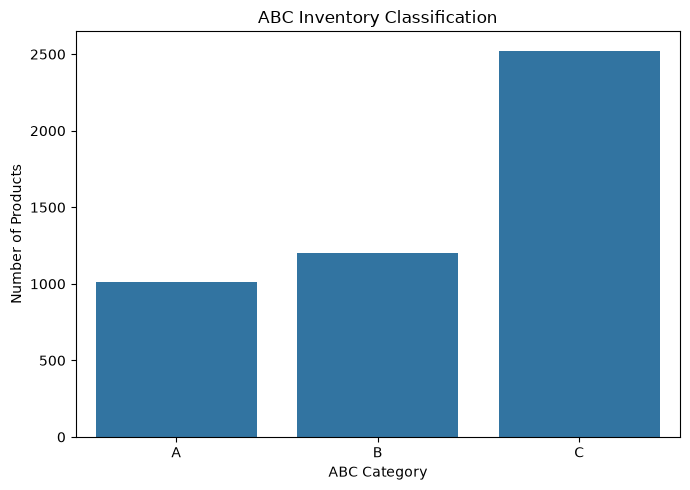

In [13]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=inventory,
    x="ABC_Class",
    order=["A", "B", "C"]
)

plt.title("ABC Inventory Classification")
plt.xlabel("ABC Category")
plt.ylabel("Number of Products")

plt.tight_layout()

plt.show()

In [8]:
def inventory_status(row):

    if row["Total_Quantity"] < row["Reorder_Level"]:
        return "Restock Soon"

    elif row["Total_Quantity"] > row["Safety_Stock"] * 2:
        return "Overstock"

    else:
        return "Healthy"

inventory["Inventory_Status"] = inventory.apply(
    inventory_status,
    axis=1
)

inventory.head()

,StockCode,Description,Total_Quantity,Total_Revenue,Total_Orders,Average_Daily_Demand,Maximum_Daily_Demand,Safety_Stock,Reorder_Level,Inventory_Status
0,10002,INFLATABLE POLITICAL GLOBE,7971,6333.76,310,25.879870,400,4200.0,181.159091,Healthy
1,10002R,ROBOT PENCIL SHARPNER,4,20.57,3,1.333333,2,21.0,9.333333,Restock Soon
2,10080,GROOVY CACTUS INFLATABLE,12,10.20,5,2.400000,6,63.0,16.800000,Restock Soon
3,10109,BENDY COLOUR PENCILS,4,1.68,1,4.000000,4,42.0,28.000000,Restock Soon
4,10120,DOGGY RUBBER,487,105.57,47,10.361702,60,630.0,72.531915,Healthy


In [14]:
inventory[
    [
        "StockCode",
        "Description",
        "ABC_Class"
    ]
].to_csv(
    "../outputs/abc_analysis.csv",
    index=False
)

print("✅ abc_analysis.csv saved successfully!")

✅ abc_analysis.csv saved successfully!


In [9]:
inventory["Inventory_Status"].value_counts()

Inventory_Status
Healthy         3448
Restock Soon     816
Overstock        468
Name: count, dtype: int64

In [15]:
inventory[
    [
        "StockCode",
        "Description",
        "Inventory_Status"
    ]
].to_csv(
    "../outputs/inventory_risk.csv",
    index=False
)

print("✅ inventory_risk.csv saved successfully!")

✅ inventory_risk.csv saved successfully!


In [16]:
inventory["Reorder_Recommendation"] = inventory["Inventory_Status"].map({
    "Restock Soon": "Reorder Immediately",
    "Healthy": "Monitor Stock",
    "Overstock": "Reduce Inventory"
})

inventory[
    [
        "StockCode",
        "Description",
        "Reorder_Recommendation"
    ]
].to_csv(
    "../outputs/reorder_recommendation.csv",
    index=False
)

print("✅ reorder_recommendation.csv saved successfully!")

✅ reorder_recommendation.csv saved successfully!


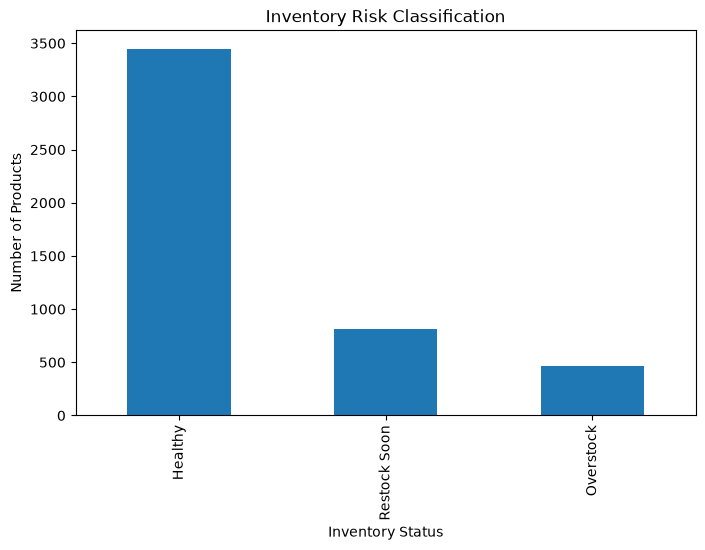

In [10]:
import matplotlib.pyplot as plt

inventory["Inventory_Status"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Inventory Risk Classification")
plt.xlabel("Inventory Status")
plt.ylabel("Number of Products")

plt.show()

In [11]:
inventory.to_csv(
    "../outputs/inventory_optimization.csv",
    index=False
)

print("✅ inventory_optimization.csv saved successfully!")

✅ inventory_optimization.csv saved successfully!


# Business Insights

### Key Findings

- ABC Analysis identifies products contributing most to total revenue.
- High-value (A) products require close inventory monitoring.
- Products marked "Restock Soon" should be prioritized for procurement.
- Overstocked items increase holding costs and should be managed carefully.
- Inventory optimization helps balance product availability with inventory investment.

# Conclusion

The inventory optimization workflow analyzes historical sales to generate inventory risk classifications and reorder recommendations.

The exported datasets support:

- Streamlit Dashboard
- Power BI Dashboard
- Procurement Planning
- Inventory Management
- Business Decision-Making